<a href="https://colab.research.google.com/github/ibtihalalf/Sdaia-Bootcamp/blob/main/Week3/M2/ex2_multi_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [8]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [9]:
url = "https://archive.ics.uci.edu/static/public/9/data.csv"
df = pd.read_csv(url)
df

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,"chevrolet,chevelle,malibu",8,307.0,130.0,3504,12.0,70,1,18.0
1,"buick,skylark,320",8,350.0,165.0,3693,11.5,70,1,15.0
2,"plymouth,satellite",8,318.0,150.0,3436,11.0,70,1,18.0
3,"amc,rebel,sst",8,304.0,150.0,3433,12.0,70,1,16.0
4,"ford,torino",8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,"ford,mustang,gl",4,140.0,86.0,2790,15.6,82,1,27.0
394,"vw,pickup",4,97.0,52.0,2130,24.6,82,2,44.0
395,"dodge,rampage",4,135.0,84.0,2295,11.6,82,1,32.0
396,"ford,ranger",4,120.0,79.0,2625,18.6,82,1,28.0


### Step 2.a Assign variables `X` to the features and `y` to the target

In [35]:
df[['cylinders', 'model_year', 'origin']] = df[['cylinders', 'model_year', 'origin']].astype('category')
X = df.drop(columns=["mpg" , "car_name"])
y = df["mpg"]

### Step 2.b print the type of each

In [36]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

The target is numerical and the task is regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [37]:
print("X shape : " , X.shape)
print("y shape : " , y.shape)

X shape :  (398, 7)
y shape :  (398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [38]:
# Summary for numerical columns
df.describe()

,displacement,horsepower,weight,acceleration,mpg
count,398.000000,392.000000,398.000000,398.000000,398.000000
mean,193.425879,104.469388,2970.424623,15.568090,23.514573
std,104.269838,38.491160,846.841774,2.757689,7.815984
min,68.000000,46.000000,1613.000000,8.000000,9.000000
25%,104.250000,75.000000,2223.750000,13.825000,17.500000
50%,148.500000,93.500000,2803.500000,15.500000,23.000000
75%,262.000000,126.000000,3608.000000,17.175000,29.000000
max,455.000000,230.000000,5140.000000,24.800000,46.600000


In [39]:
# Summary for categorical columns
df.describe(include='category')

,car_name,cylinders,model_year,origin
count,398,398,398,398
unique,5,5,13,3
top,4,4,73,1
freq,204,204,40,249


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

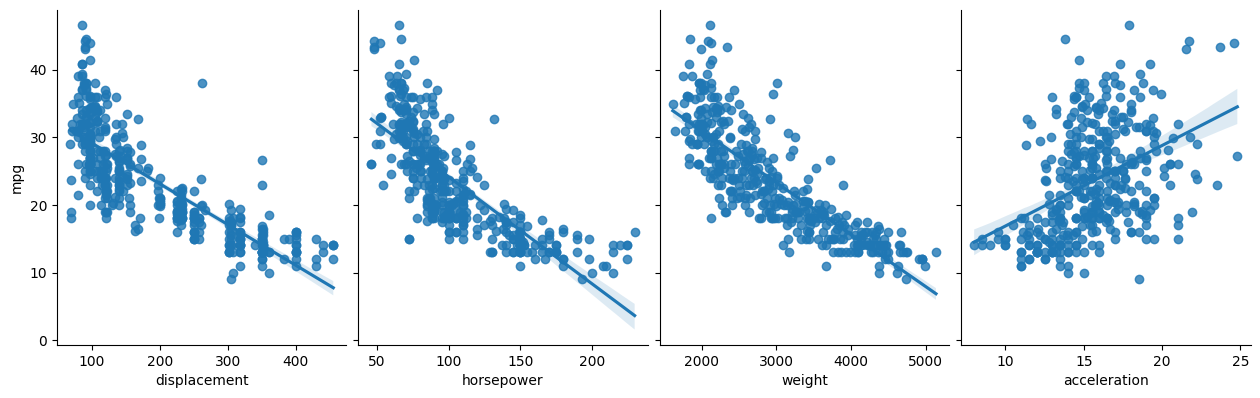

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

num_features = ['displacement', 'horsepower', 'weight', 'acceleration']

sns.pairplot(
    df,
    x_vars=num_features,
    y_vars='mpg',
    height=4,
    aspect=0.8,
    kind='reg'
)

plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer





In [ ]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

### Step 9.a Fit the pipeline on the training set

In [ ]:
pipe.fit(X_train, y_train)

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

### Step 10. Evaluate the pipeline on the test set

In [ ]:
score = pipe.score(X_test, y_test)